## Useful references

### Refs
- [RDKit Documentation](https://www.rdkit.org/docs/GettingStartedInPython.html)
- [PubChem](https://pubchem.ncbi.nlm.nih.gov/) - find SDF files for molecules
- [YouTube Tutorial](https://www.youtube.com/watch?v=NozaWUkJ3YM)

### Workflow Suggestions
> After modifying classes from `src` directory, **Restart NoteBook Kernel** is required 
- Recommended action after changing files in `src`: Restart -> Run All

## Imports

In [113]:
from collections import Counter

from src import DIAMAG_COMPOUND_ATOMS_SUBDIR
from src.constants.bond_types import RELEVANT_BOND_TYPES
from src.core.compound import MBCompound
from src.core.substruct_matcher import (
    BondMatchCandidate,
    MBSubstructMatcher,
    SubstructMatchResult,
)
from src.loader import MBLoader, MBMolecule
from src.renderer.renderer import Renderer
from src.utils.ui import Theme
from tests.data.substruct_matching_tests import SUBSTRUCT_MATCH_TESTS


## Filter specific test

In [114]:
filter_test_id = [377]  # int, list of ints, or None for all tests

## Find substructure matches test
> - Identical as **test_substruct_matcher.py**, but allows to **visualize** specific test case

In [115]:
failures: list[str] = []
mols: list[MBMolecule] = []
results: list[SubstructMatchResult] = []

_ids = None if filter_test_id is None else ({filter_test_id} if isinstance(filter_test_id, int) else set(filter_test_id))
for bond_type_test in [bt for bt in SUBSTRUCT_MATCH_TESTS if _ids is None or bt.id in _ids]:
    mol: MBMolecule = MBLoader.MolFromSmiles(smiles=bond_type_test.SMILES)
    mols.append(mol)

    results.append(MBSubstructMatcher.GetMatches(mol=mol))

## Visual Representation

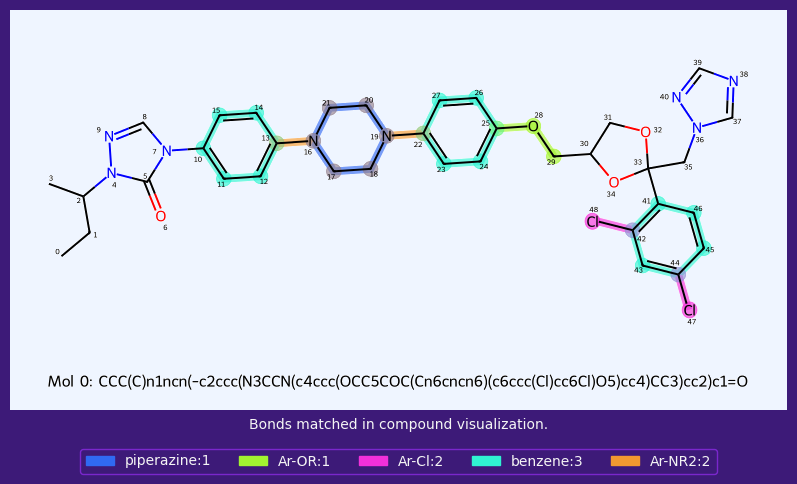

In [116]:
display(
    Renderer(Theme.LoFi).GetMoleculesGridImg(
        mols=[m.ToRDKit() for m in mols],
        highlightAtomLists=[r.highlightAtomList for r in results],
        highlightAtomGroupsPerMol=[r.highlightAtomGroups for r in results],
        matchesCountersPerMol=[r.matchesCounter for r in results],
        size=(777, 400),
        mols_per_row=1,
        label="Bonds matched in compound visualization.",
        showLegend=True,
        showAtomIndexes=True,
        highlightAlpha=0.66,
    )
)